# 05 — Anomaly Detection (Isolation Forest)

**PredictAI — Predictive Maintenance & Machine Health Platform**

Notebook 04 produced a supervised classifier at 0.898 PR-AUC. So why build an
unsupervised detector that will score far worse?

### The argument

The supervised model can only recognise the four failure modes present in its training
labels. A deployed machine will eventually fail in a way nobody labelled — a new
bearing fault, a coolant problem, a sensor drift. To the classifier that looks like
ordinary operation, and it will report a low failure probability *with confidence*.

An anomaly detector makes no assumption about failure modes. It learns what normal
looks like and flags departures from it. The two models answer different questions:

| | Supervised classifier | Anomaly detector |
|---|---|---|
| Question | "Is this one of the failures I was taught?" | "Is this unlike normal operation?" |
| Needs labels | yes | no |
| Catches novel faults | no | yes |
| Precision on known modes | high | low |

This notebook builds the detector, shows it is clearly worse as a general failure
predictor, and then runs an experiment that demonstrates why it earns its place anyway.

In [21]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import IsolationForest

from ml import data as D
from ml.preprocessing.tabular import to_model_matrix
from ml.evaluation.metrics import evaluate, record
from ml.paths import MODELS
from ml.viz import set_style, save_fig, OK, BAD, NEUTRAL, WARN, ACCENT

set_style()
pd.set_option("display.width", 150)

df = D.load_clean()
train, val, test = D.apply_split(df)
X_train, X_val, X_test = to_model_matrix(train), to_model_matrix(val), to_model_matrix(test)
y_train, y_val, y_test = (x[D.TARGET].to_numpy() for x in (train, val, test))

## 1. Semi-supervised framing

Pure unsupervised training on *all* rows would let the 3.4% failures contaminate the
model's notion of normal. The realistic deployment setup is **semi-supervised**: a
newly commissioned machine produces months of normal operation before anything breaks,
so the detector is fitted on known-good data only.

This is also the honest framing for the portfolio. Fitting on all rows and then
evaluating on the same rows would flatter the result.

In [22]:
X_normal = X_train[y_train == 0]
print(f"Fitting on {len(X_normal):,} known-normal training rows")
print(f"Withheld    {int(y_train.sum())} failures — never seen during fitting")

iso = IsolationForest(
    n_estimators=300,
    contamination=0.034,   # matches the observed base rate; see section 3
    max_samples="auto",
    random_state=D.RANDOM_SEED,
    n_jobs=4,
)
iso.fit(X_normal)


def anomaly_score(model, X):
    """Higher = more anomalous. sklearn's score_samples is inverted by convention."""
    return -model.score_samples(X)


s_val = anomaly_score(iso, X_val)
print(f"\nValidation anomaly scores: min {s_val.min():.3f}, max {s_val.max():.3f}")

Fitting on 5,797 known-normal training rows
Withheld    203 failures — never seen during fitting

Validation anomaly scores: min 0.407, max 0.652


## 2. Do anomaly scores separate failures?

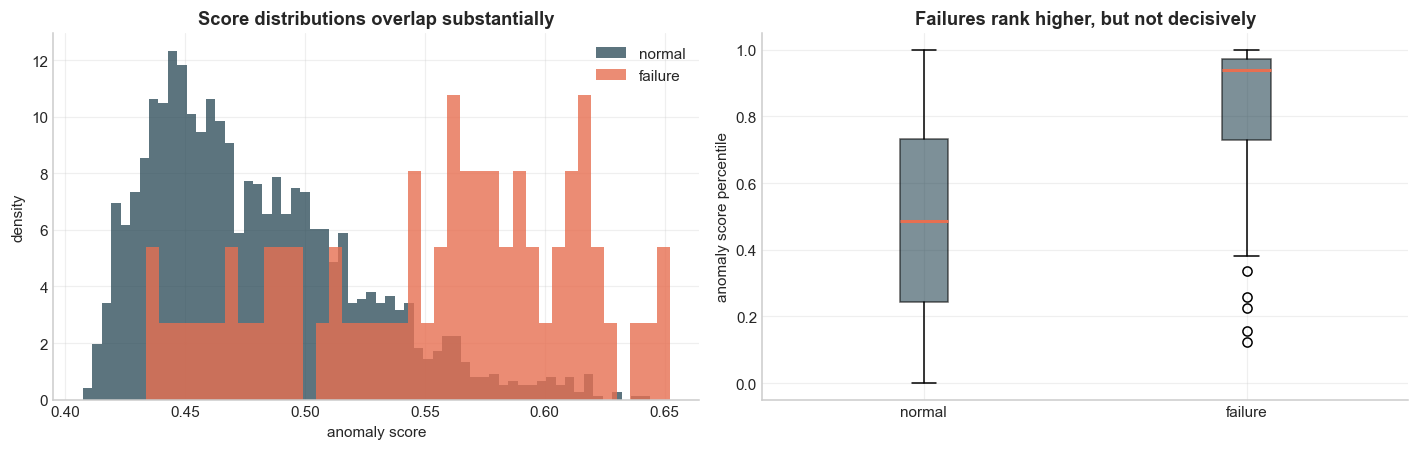

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
ax.hist(s_val[y_val == 0], bins=60, color=NEUTRAL, alpha=0.75, density=True, label="normal")
ax.hist(s_val[y_val == 1], bins=40, color=BAD, alpha=0.8, density=True, label="failure")
ax.set_xlabel("anomaly score"); ax.set_ylabel("density")
ax.set_title("Score distributions overlap substantially")
ax.legend()

ax = axes[1]
pct = pd.Series(s_val).rank(pct=True)
ax.boxplot([pct[y_val == 0], pct[y_val == 1]], labels=["normal", "failure"],
           patch_artist=True,
           boxprops=dict(facecolor=NEUTRAL, alpha=0.6),
           medianprops=dict(color=BAD, lw=2))
ax.set_ylabel("anomaly score percentile")
ax.set_title("Failures rank higher, but not decisively")
save_fig("05_score_distributions")
plt.show()

In [24]:
s_val_norm = (s_val - s_val.min()) / (s_val.max() - s_val.min())
m_iso = evaluate(y_val, s_val_norm)
print(f"Isolation Forest as a failure detector (validation):")
print(f"  PR-AUC  {m_iso['pr_auc']:.3f}")
print(f"  ROC-AUC {m_iso['roc_auc']:.3f}")
print(f"\nFor reference, XGBoost (notebook 04) reached PR-AUC 0.881 on the same split.")

Isolation Forest as a failure detector (validation):
  PR-AUC  0.287
  ROC-AUC 0.831

For reference, XGBoost (notebook 04) reached PR-AUC 0.881 on the same split.


**0.287 PR-AUC versus 0.881.** As a general-purpose failure predictor the anomaly
detector is roughly a third as good, and that is the expected and correct result — it
was never shown a single failure. Reporting it as a competitor to the classifier would
be a category error. Its job is different, and section 5 tests that job directly.

## 3. The contamination parameter does nothing to ranking quality

In [25]:
rows = []
for c in [0.005, 0.01, 0.02, 0.034, 0.05, 0.10, 0.20]:
    f = IsolationForest(n_estimators=300, contamination=c,
                        random_state=D.RANDOM_SEED, n_jobs=4).fit(X_normal)
    s = anomaly_score(f, X_val)
    sn = (s - s.min()) / (s.max() - s.min())
    r = evaluate(y_val, sn)
    flagged = int((f.predict(X_val) == -1).sum())
    rows.append({"contamination": c, "pr_auc": round(r["pr_auc"], 3),
                 "roc_auc": round(r["roc_auc"], 3), "rows flagged": flagged})
print(pd.DataFrame(rows).to_string(index=False))

 contamination  pr_auc  roc_auc  rows flagged
         0.005   0.287    0.831            19
         0.010   0.287    0.831            42
         0.020   0.287    0.831            69
         0.034   0.287    0.831            97
         0.050   0.287    0.831           137
         0.100   0.287    0.831           248
         0.200   0.287    0.831           446


PR-AUC and ROC-AUC are **identical across every contamination value**, while the number
of rows flagged changes by an order of magnitude.

`contamination` does not change how the forest scores points — it only sets the cut
point applied to those scores. It is a threshold parameter wearing a hyperparameter's
clothing. This is the same lesson as notebooks 03 and 04: **ranking quality and
operating point are separate concerns**, and here it is unusually clean because the
ranking is provably untouched.

Practical consequence: never tune `contamination` by cross-validating AUC — it cannot
move. Set it from the alert budget the maintenance team can actually service.

## 4. Which failure modes does it catch?

In [26]:
val_s = val.copy()
val_s["pct"] = pd.Series(s_val).rank(pct=True).to_numpy()
fails = val_s[val_s[D.TARGET] == 1]

rows = [{"group": "Normal rows", "n": int((y_val == 0).sum()),
         "mean percentile": round(val_s.loc[val_s[D.TARGET] == 0, "pct"].mean(), 3)}]
for mode in ["hdf", "pwf", "osf"]:
    sub = fails[fails[mode] == 1]
    rows.append({"group": D.FAILURE_MODE_NAMES[mode], "n": len(sub),
                 "mean percentile": round(sub["pct"].mean(), 3)})
twf = fails[(fails["twf"] == 1) & (fails[["hdf", "pwf", "osf"]].max(axis=1) == 0)]
rows.append({"group": "TWF only", "n": len(twf), "mean percentile": round(twf["pct"].mean(), 3)})
print(pd.DataFrame(rows).to_string(index=False))

                   group    n  mean percentile
             Normal rows 1932            0.489
Heat Dissipation Failure   19            0.660
           Power Failure   23            0.969
      Overstrain Failure   20            0.952
                TWF only    5            0.596


The pattern is instructive. Failure modes defined on **extreme sensor values** (power
starvation/overload, overstrain) rank high, because extreme values are exactly what an
isolation-based method isolates quickly. Modes defined on a **conjunction of
individually unremarkable values** — HDF needs low temp gap *and* low rpm, neither
unusual alone — rank far lower. And TWF, which has no sensor signature at all, sits
near the normal population.

So the detector is not a weaker version of the classifier. It has a *different bias*:
it sees outliers, not rules.

## 5. The experiment that justifies the model

The claim to test: **when a failure mode is absent from the training labels, the
supervised model fails silently and the anomaly detector still flags it.**

Setup: relabel every overstrain (OSF) failure in the training set as normal, so the
classifier has never seen one. The anomaly detector is unchanged — it never used labels
anyway. Then score the OSF failures in validation, which both models see for the first
time.

In [27]:
blind_mask = ~((train[D.TARGET] == 1) & (train["osf"] == 1))
y_blind = train[D.TARGET].where(blind_mask, 0).to_numpy()
print(f"OSF failures hidden from the classifier: {int(y_train.sum() - y_blind.sum())}")

clf_blind = xgb.XGBClassifier(n_estimators=300, max_depth=5,
                              random_state=D.RANDOM_SEED, eval_metric="aucpr", n_jobs=4)
clf_blind.fit(X_train, y_blind)
p_blind = clf_blind.predict_proba(X_val)[:, 1]

osf_val = val_s[(val_s[D.TARGET] == 1) & (val_s["osf"] == 1)]
normal_val = val_s[val_s[D.TARGET] == 0]

print(f"\nUnseen OSF failures in validation: {len(osf_val)}")
print(f"\n{'':30s} {'OSF failures':>14s} {'normal rows':>14s}")
print(f"{'Classifier failure prob':30s} {p_blind[osf_val.index].mean():>14.4f} "
      f"{p_blind[normal_val.index].mean():>14.4f}")
print(f"{'IsoForest anomaly percentile':30s} {osf_val['pct'].mean():>14.3f} "
      f"{normal_val['pct'].mean():>14.3f}")

OSF failures hidden from the classifier: 62

Unseen OSF failures in validation: 20

                                 OSF failures    normal rows
Classifier failure prob                0.0006         0.0066
IsoForest anomaly percentile            0.952          0.489


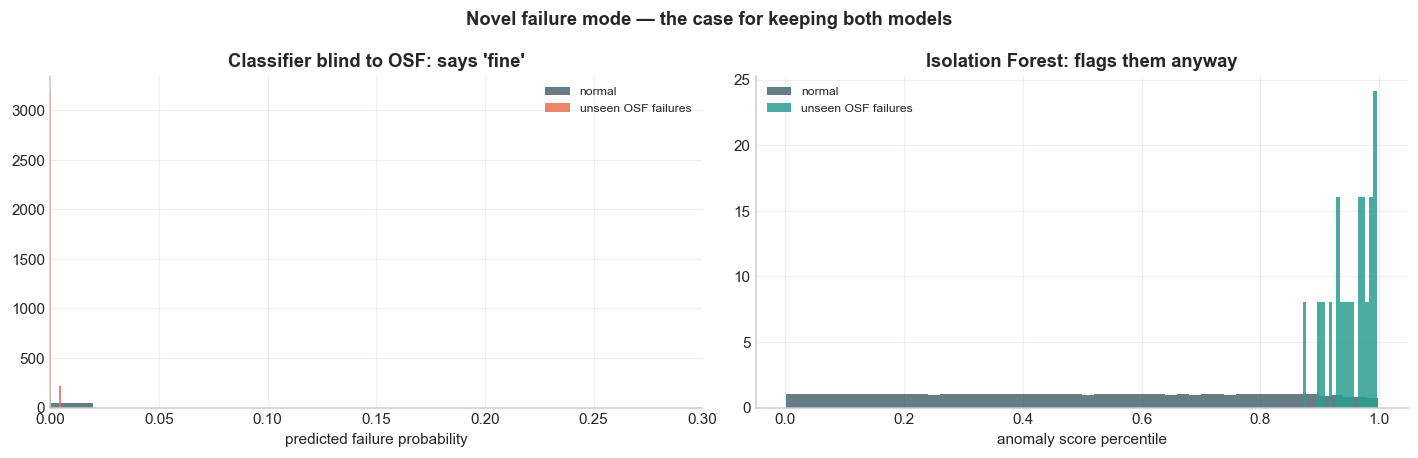

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
ax.hist(p_blind[normal_val.index], bins=50, color=NEUTRAL, alpha=0.7, density=True, label="normal")
ax.hist(p_blind[osf_val.index], bins=20, color=BAD, alpha=0.85, density=True, label="unseen OSF failures")
ax.set_xlim(0, 0.3); ax.set_xlabel("predicted failure probability")
ax.set_title("Classifier blind to OSF: says 'fine'")
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(normal_val["pct"], bins=50, color=NEUTRAL, alpha=0.7, density=True, label="normal")
ax.hist(osf_val["pct"], bins=20, color=OK, alpha=0.85, density=True, label="unseen OSF failures")
ax.set_xlabel("anomaly score percentile")
ax.set_title("Isolation Forest: flags them anyway")
ax.legend(fontsize=8)

fig.suptitle("Novel failure mode — the case for keeping both models", fontweight="bold")
save_fig("05_novel_fault_experiment")
plt.show()

### Result

The classifier assigns the unseen overstrain failures a mean probability of **0.0005**
— indistinguishable from normal, and confidently so. It is not uncertain; it is wrong.

The Isolation Forest places the same rows at the **95th percentile** of anomaly score
against a 49th-percentile baseline for normal rows, having never been told that
overstrain exists.

This is the concrete argument for the two-model architecture in the PredictAI
dashboard. The classifier drives the **failure probability** and the named-mode alerts;
the anomaly detector drives a separate **"unusual behaviour"** signal that does not
claim to know what is wrong, only that something is. A system with only the classifier
would have gone quiet on a real fault.

## 6. Operating point and test evaluation

Set from an alert budget rather than an AUC: the team can service roughly 5% of the
fleet per cycle, so flag the top 5% of anomaly scores.

In [29]:
threshold_pct = 0.95
cut = np.quantile(s_val, threshold_pct)

s_test = anomaly_score(iso, X_test)
s_test_norm = (s_test - s_test.min()) / (s_test.max() - s_test.min())
m_test = evaluate(y_test, s_test_norm, threshold=(cut - s_test.min()) / (s_test.max() - s_test.min()))

record("Isolation Forest", "test", m_test,
       notes="semi-supervised (fitted on normal rows only); threshold = 95th pct of val scores")
print(pd.Series(m_test).to_string())

threshold        0.696000
accuracy         0.948000
precision        0.308511
recall           0.426471
f1               0.358025
roc_auc          0.866345
pr_auc           0.289785
tn            1867.000000
fp              65.000000
fn              39.000000
tp              29.000000
cost         20150.000000


## 7. Save the detector

In [30]:
det_dir = MODELS / "anomaly_detector"
det_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(iso, det_dir / "isolation_forest.pkl")

(det_dir / "model_metadata.json").write_text(json.dumps({
    "model_type": "IsolationForest",
    "training": "semi-supervised — fitted on known-normal training rows only",
    "n_training_rows": int(len(X_normal)),
    "features": list(X_train.columns),
    "score_convention": "higher = more anomalous (negated score_samples)",
    "raw_score_threshold": float(cut),
    "threshold_rule": "95th percentile of validation scores (alert budget, not AUC)",
    "test_metrics": {k: round(v, 4) for k, v in m_test.items() if isinstance(v, (int, float))},
    "purpose": "novel-fault detection; NOT a replacement for the supervised classifier",
    "known_limits": "weak on conjunction-defined modes (HDF) and on TWF, which has no "
                    "sensor signature; strong on extreme-value modes (PWF, OSF)",
    "random_seed": D.RANDOM_SEED,
}, indent=2))

for f in sorted(det_dir.iterdir()):
    print(f"  {f.name:28s} {f.stat().st_size:>9,} bytes")

  isolation_forest.pkl         4,318,761 bytes
  model_metadata.json              1,059 bytes


The raw score threshold is stored, not the percentile — percentiles are only meaningful
relative to a scored population, and the inference service scores one machine at a time.

## Findings

1. **As a failure predictor the detector is much worse than the classifier** (0.287 vs
   0.881 PR-AUC), which is the expected result for a model that never saw a label.
2. **`contamination` does not affect ranking quality at all** — identical AUCs across a
   40x range. It is a threshold, and should be set from an alert budget.
3. **It has a different bias, not a weaker one.** Extreme-value modes (PWF, OSF) rank
   high; conjunction-defined (HDF) and signature-free (TWF) modes do not.
4. **The novel-fault experiment is the justification.** With OSF hidden from its
   labels, the classifier scored those failures at 0.0005 — confidently wrong — while
   the detector put them at the 95th percentile. This is why both models ship.

### Next
`06_autoencoder.ipynb` — a neural reconstruction-based detector, compared against this
one on the same split and the same novel-fault test.